<a href="https://colab.research.google.com/github/Wolynes/Environmental-Data-Science-Course/blob/main/FWE458_HW5_timeseriesgriddeddata_Wolynes_Margrethe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5: Time Series & Gridded Climate Data
## F&W ECOL 458: Environmental Data Science
### Covers Lectures 10 & 11

## [Your Name]

**Instructions:**
- Complete all code cells marked with `# YOUR CODE HERE`
- Answer all written-response questions in the provided markdown cells
- Run all cells to make sure your code works before submitting
- Push the completed `.ipynb` file to your homework github repo
- Submit the link to the completed `.ipynb` file in your homework github repo to canvas

---

## Setup

In [1]:
# Run this cell first — installs and imports
!pip install xarray netCDF4 statsmodels cartopy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.2 MB/s eta 0:00:00


In [2]:
# Mount Google Drive (the NetCDF file is stored there)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

---
## Problem 1: Time Series Analysis of Simulated Weather Data (50 pts)

In this problem you will practice the core time-series skills from Lecture 10: resampling, rolling averages, and seasonal decomposition. We'll use a synthetic daily weather dataset for Madison, WI that has realistic seasonal patterns.

Run the cell below to generate the data — **do not modify it.**

In [4]:
# === DO NOT MODIFY THIS CELL — it creates the dataset ===
np.random.seed(458)

dates = pd.date_range('2018-01-01', '2024-12-31', freq='D')
n = len(dates)
doy = dates.dayofyear

# Seasonal cycle + slight warming trend + noise
seasonal = 16 * np.sin(2 * np.pi * (doy - 80) / 365)
trend = np.linspace(0, 1.5, n)
noise = np.random.normal(0, 4, n)
temperature = 8 + seasonal + trend + noise  # °C

# Precipitation (exponential with seasonal modulation)
precip_rate = 2.5 + 1.0 * np.sin(2 * np.pi * (doy - 120) / 365)
precipitation = np.random.exponential(precip_rate)  # mm

weather = pd.DataFrame({
    'date': dates,
    'temperature_c': temperature,
    'precipitation_mm': precipitation
})

# Set date as index (DatetimeIndex)
weather = weather.set_index('date')

print(f"Dataset: {len(weather)} days, {weather.index[0].date()} to {weather.index[-1].date()}")
weather.head()

Dataset: 2557 days, 2018-01-01 to 2024-12-31


,temperature_c,precipitation_mm
date,,
2018-01-01,-9.181843,0.431327
2018-01-02,-9.816574,3.576616
2018-01-03,-9.838835,3.675735
2018-01-04,-1.018871,1.621691
2018-01-05,-0.786900,1.075056


### Part A — Resampling (15 pts)

**A1 (5 pts).** Resample the daily temperature data to **monthly means**. Store the result in a variable called `monthly_temp`. Print the first 12 values.

In [5]:
# YOUR CODE HERE
# Resampling daily data to monthly means
monthly_temp = weather['temperature_c'].resample('M').mean()

print(f"Original: {len(weather)} daily observations")
print(f"Resampled: {len(monthly_temp)} monthly observations")
monthly_temp.head(12)

Original: 2557 daily observations
Resampled: 84 monthly observations


,temperature_c
date,
2018-01-31,-5.912906
2018-02-28,-1.930791
2018-03-31,5.660184
2018-04-30,15.965819
2018-05-31,19.914196
2018-06-30,23.437270
2018-07-31,22.150953
2018-08-31,16.451168
2018-09-30,9.757707


**A2 (5 pts).** Resample the daily precipitation data to **annual totals** (sum). Store the result in a variable called `annual_precip`. Print all values.

In [6]:
# YOUR CODE HERE
precipitation_mm = weather['precipitation_mm']
annual_precip = precipitation_mm.resample('Y').sum()
annual_precip

,precipitation_mm
date,
2018-12-31,925.672092
2019-12-31,979.133318
2020-12-31,879.932925
2021-12-31,932.632134
2022-12-31,827.074237
2023-12-31,912.256837
2024-12-31,1048.618810


**A3 (5 pts).** Make a bar plot of `annual_precip` with year on the x-axis and total precipitation (mm) on the y-axis. Add axis labels and a title.

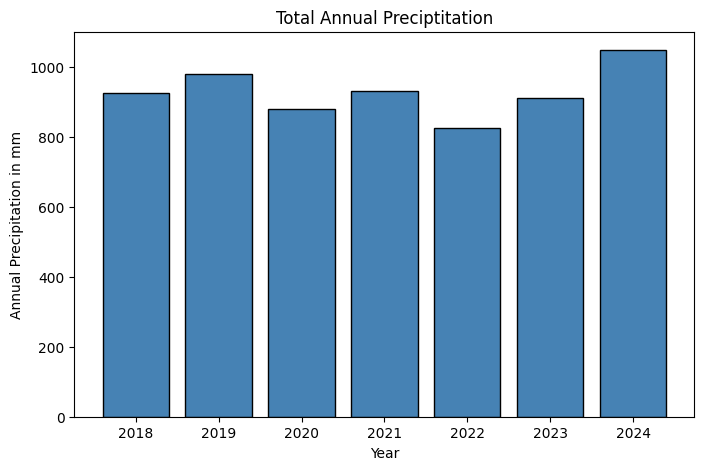

In [15]:
# YOUR CODE HERE
precipitation_mm = weather['precipitation_mm']
annual_precip = precipitation_mm.resample('Y').sum()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(annual_precip.index.year, annual_precip.values,
       color='steelblue', edgecolor='black')

ax.set_xlabel('Year')
ax.set_ylabel('Annual Precipitation in mm')
ax.set_title('Total Annual Preciptitation')

plt.show()

### Part B — Rolling Averages (15 pts)

**B1 (5 pts).** Calculate a **30-day rolling mean** of temperature. Store it in a new column called `temp_30day_ma`.

In [19]:
# YOUR CODE HERE
weather['temp_30day_ma'] = weather['temperature_c'].rolling(window=30).mean()

print(weather[['temperature_c', 'temp_30day_ma']].head(30))
print(f"NaN values in 30-day MA: {weather['temp_30day_ma'].isna().sum()}")

            temperature_c  temp_30day_ma
date                                    
2018-01-01      -9.181843            NaN
2018-01-02      -9.816574            NaN
2018-01-03      -9.838835            NaN
2018-01-04      -1.018871            NaN
2018-01-05      -0.786900            NaN
2018-01-06      -9.409719            NaN
2018-01-07      -6.396947            NaN
2018-01-08      -1.783123            NaN
2018-01-09      -6.058594            NaN
2018-01-10     -14.393448            NaN
2018-01-11     -11.504796            NaN
2018-01-12      -9.092930            NaN
2018-01-13      -7.013657            NaN
2018-01-14      -3.924651            NaN
2018-01-15      -8.286756            NaN
2018-01-16      -4.919036            NaN
2018-01-17      -4.394174            NaN
2018-01-18      -4.540166            NaN
2018-01-19      -7.081160            NaN
2018-01-20      -2.019663            NaN
2018-01-21      -4.898241            NaN
2018-01-22     -10.129009            NaN
2018-01-23      

**B2 (10 pts).** Create a figure that shows **one year of data (2023)** with:
- The raw daily temperature as a thin, semi-transparent line
- The 30-day rolling mean as a thicker line on top
- A legend, axis labels, and a title

*Hint:* Use `.loc['2023']` to select the year.

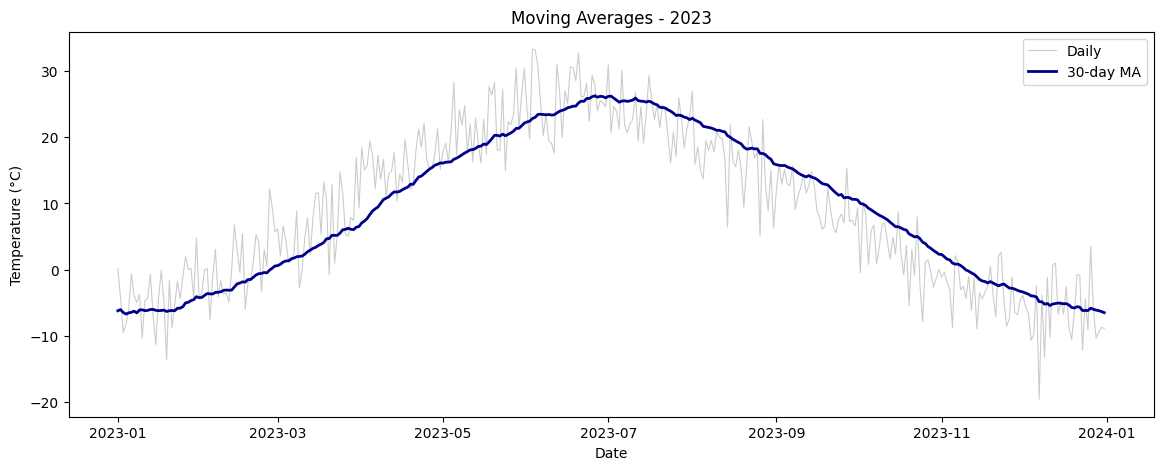

In [21]:
# YOUR CODE HERE
# Visualize smoothing effect
fig, ax = plt.subplots(figsize=(14, 5))

# Plot one year for clarity
year_data = weather.loc['2023']

ax.plot(year_data.index, year_data['temperature_c'],
        alpha=0.4, linewidth=0.8, label='Daily', color='gray')
ax.plot(year_data.index, year_data['temp_30day_ma'],
        linewidth=2, label='30-day MA', color='darkblue')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Moving Averages - 2023')
ax.legend()

plt.show()

### Part C — Seasonal Decomposition (20 pts)

**C1 (5 pts).** Use `seasonal_decompose()` from statsmodels to decompose `monthly_temp` (the monthly means you created in Part A). Use `period=12` for an annual cycle. Store the result in a variable called `decomp`.

In [24]:
# Perform decomposition
decomp = seasonal_decompose(
    monthly_temp,
    model='additive',
    period=12
)

# The result contains trend, seasonal, and residual components
print("Components:")
print(f"  - Trend: {type(decomp.trend)}")
print(f"  - Seasonal: {type(decomp.seasonal)}")
print(f"  - Residual: {type(decomp.resid)}")

Components:
  - Trend: <class 'pandas.core.series.Series'>
  - Seasonal: <class 'pandas.core.series.Series'>
  - Residual: <class 'pandas.core.series.Series'>


**C2 (5 pts).** Plot the four decomposition panels (observed, trend, seasonal, residual) using `decomp.plot()`. Set the figure size to (14, 10).

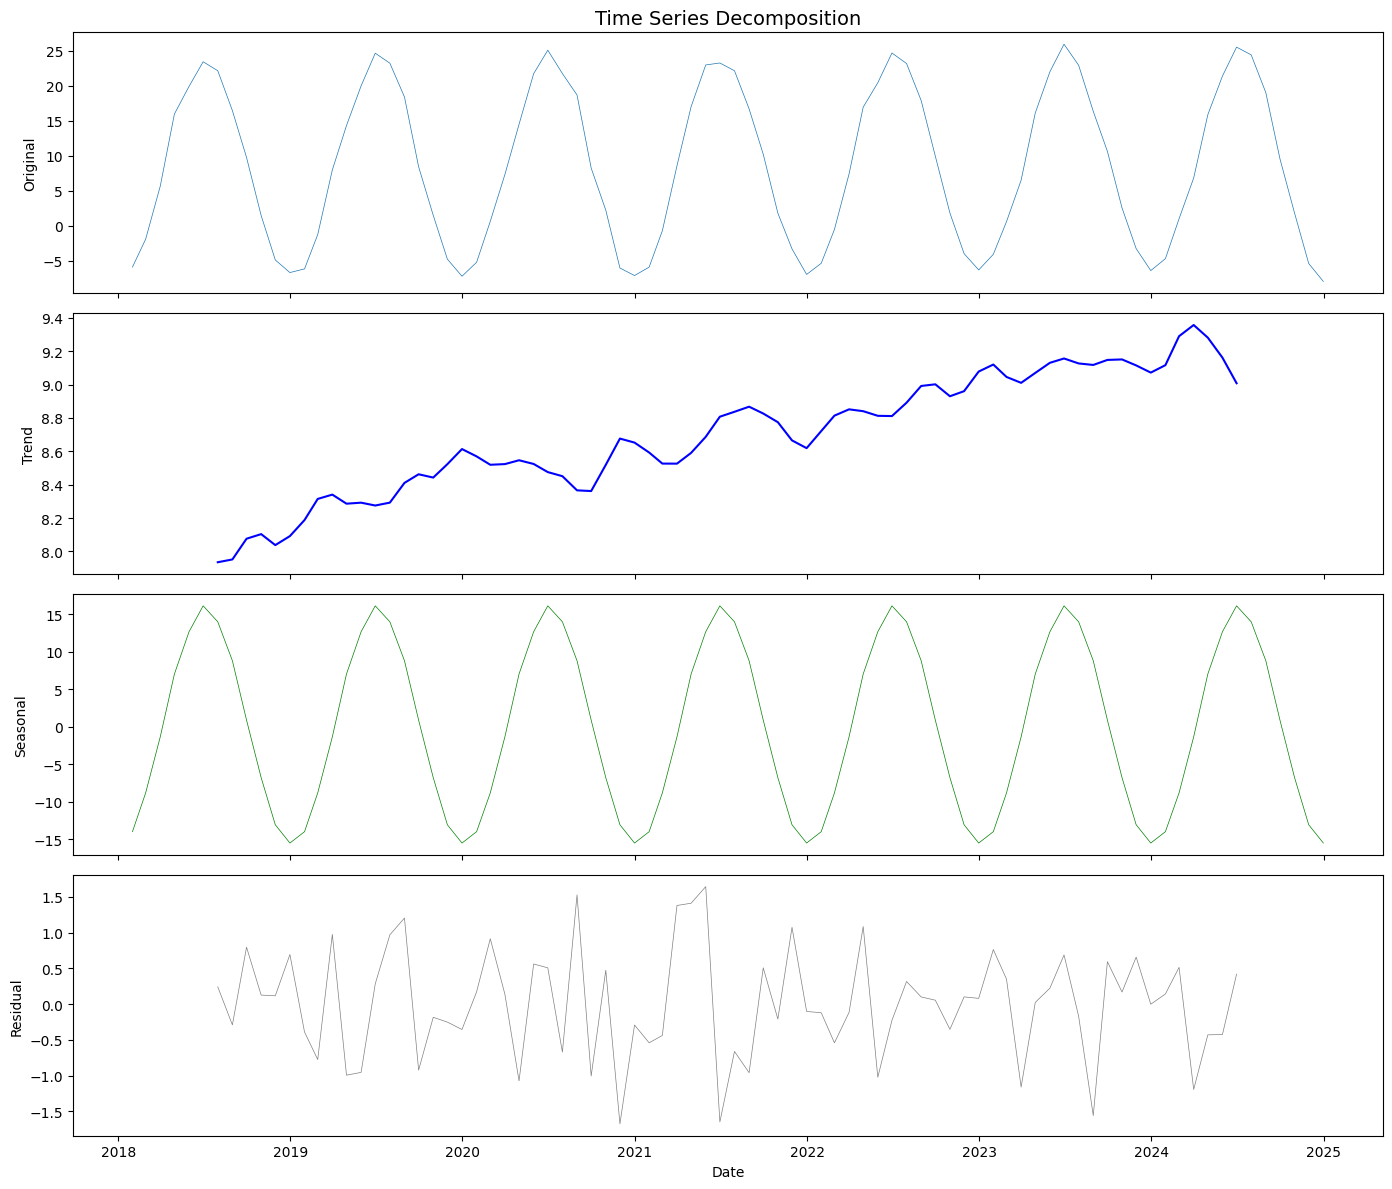

In [28]:
# YOUR CODE HERE
# Visualize decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Original data (Note: decomp.observed would be the observed component used for decomposition)
axes[0].plot(monthly_temp.index, decomp.observed, linewidth=0.5)
axes[0].set_ylabel('Original')
axes[0].set_title('Time Series Decomposition', fontsize=14)

# Trend
axes[1].plot(decomp.trend.index, decomp.trend, color='blue', linewidth=1.5)
axes[1].set_ylabel('Trend')

# Seasonal
axes[2].plot(decomp.seasonal.index, decomp.seasonal, color='green', linewidth=0.5)
axes[2].set_ylabel('Seasonal')

# Residual
axes[3].plot(decomp.resid.index, decomp.resid, color='gray', linewidth=0.5)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()

**C3 (10 pts).** Answer the following questions in 1–2 sentences each.

1. Looking at the **trend** component: does temperature appear to be increasing, decreasing, or staying the same over the 7-year record?
2. Looking at the **seasonal** component: approximately what is the range (warmest minus coldest) of the annual temperature cycle in °C?
3. Why did we use `period=12` instead of `period=365` here?

*Your answers:*

1. The temperature trend in this data appears to be increasing over the seven year record.
2. The range of the cycle in ºC is about 32ºC
3. We used period=12 instead of period=365 here because we wanted to visualize the decompostion of the annual cycle based upon monthly data, a period of 365 would correspond to daily data.


---
## Problem 2: Gridded Climate Data with xarray (50 pts)

In this problem you will work with the real **CRU TS4.09 temperature dataset** (CONUS subset) from Lecture 11. You'll practice selecting data by coordinates and time, computing climate anomalies, and drawing a map.

Run the cell below to load the data — **do not modify it.**

In [44]:
# === DO NOT MODIFY THIS CELL — it loads the CRU dataset ===
cru_path = '/content/drive/MyDrive/cru_ts4.09.1901.2024.tmp.conus.nc'
ds = xr.open_dataset(cru_path)

print(f"Loaded CRU TS4.09 CONUS temperature dataset")
print(f"  Time: {pd.to_datetime(ds.time.values[0]).date()} to {pd.to_datetime(ds.time.values[-1]).date()}")
print(f"  Lat:  {float(ds.lat.min()):.2f}°N to {float(ds.lat.max()):.2f}°N")
print(f"  Lon:  {float(ds.lon.min()):.2f}° to {float(ds.lon.max()):.2f}°")
print(f"  Shape (time, lat, lon): {ds['tmp'].shape}")
ds

Loaded CRU TS4.09 CONUS temperature dataset
  Time: 1901-01-16 to 2024-12-16
  Lat:  24.75°N to 49.25°N
  Lon:  -124.75° to -66.75°
  Shape (time, lat, lon): (1488, 50, 117)


<xarray.Dataset> Size: 174MB
Dimensions:  (time: 1488, lat: 50, lon: 117)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2024-12-16
  * lat      (lat) float32 200B 24.75 25.25 25.75 26.25 ... 48.25 48.75 49.25
  * lon      (lon) float32 468B -124.8 -124.2 -123.8 ... -67.75 -67.25 -66.75
Data variables:
    tmp      (time, lat, lon) float32 35MB ...
    stn      (time, lat, lon) float64 70MB ...
    mae      (time, lat, lon) float32 35MB ...
    maea     (time, lat, lon) float32 35MB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.09 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2503051245. Data generated from:tmp.2503051121.dtb
    history:      CONUS subset (-125.0,24.5)-(-66.5,49.5) extracted from cru_...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

### Part A — Selecting Data (15 pts)

**A1 (5 pts).** Extract the temperature time series for a grid cell near **Denver, CO** (latitude ≈ 39.7°N, longitude ≈ −105.0°). Use `method='nearest'` in `.sel()`. Store the result in a variable called `denver_temp`. Print the shape and the coordinates of the nearest grid point.

In [45]:
# YOUR CODE HERE

denver_temp = ds['tmp'].sel(lat=39.7, lon=-105.0, method='nearest')


print("Shape:", denver_temp.shape)


print("Nearest latitude:", float(denver_temp.lat.values))
print("Nearest longitude:", float(denver_temp.lon.values))

Shape: (1488,)
Nearest latitude: 39.75
Nearest longitude: -104.75


**A2 (5 pts).** Select all temperature data for the month of **January 2010**. Store it in a variable called `jan_2010`. Print its shape.

In [47]:
# YOUR CODE HERE
jan_2010 = ds['tmp'].sel(time='2010-01')

print(jan_2010.shape)

(1, 50, 117)


**A3 (5 pts).** Extract a regional subset covering the **Southeast US**: latitude 25°N to 37°N, longitude −92° to −75°. Store it in a variable called `southeast`. Print the number of latitude and longitude grid cells.

In [48]:
# YOUR CODE HERE
# Extracting SE region
southeast = ds['tmp'].sel(lat=slice(25, 37), lon=slice(-92, -75))

# Print number of latitude and longitude grid cells
print("Number of latitude cells:", southeast.lat.size)
print("Number of longitude cells:", southeast.lon.size)

Number of latitude cells: 24
Number of longitude cells: 34


### Part B — Climate Anomalies (20 pts)

**B1 (5 pts).** Calculate the **1991–2020 monthly climatology** (i.e., the average January, average February, … average December over that 30-year baseline). Store the result in a variable called `climatology`.

*Hint:* First select the baseline period with `.sel(time=slice(...))`, then use `.groupby('time.month').mean(dim='time')`.

In [49]:
# YOUR CODE HERE

baseline = ds['tmp'].sel(time=slice('1991-01', '2020-12'))


climatology = baseline.groupby('time.month').mean(dim='time')

print(climatology.shape)

(12, 50, 117)


**B2 (5 pts).** Compute the temperature **anomaly** for the full record by subtracting the climatology from each month. Store the result in a variable called `anomaly`.

*Hint:* `anomaly = ds['tmp'].groupby('time.month') - climatology`

In [50]:
# YOUR CODE HERE
anomaly = ds['tmp'].groupby('time.month') - climatology

**B3 (10 pts).** Using the Denver grid cell from Part A, plot the **monthly anomaly time series** at that location. Your plot should include:
- The anomaly values as a line plot
- A horizontal dashed line at y = 0
- Axis labels and a title that mentions the baseline period

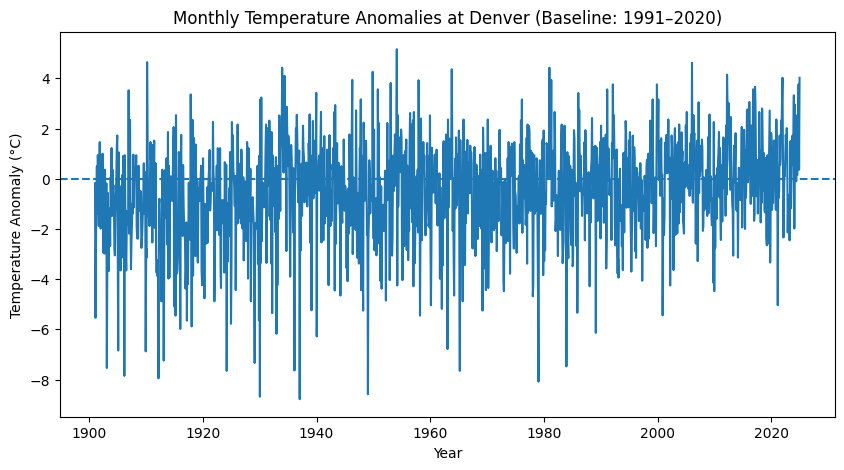

In [51]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

denver_anomaly = anomaly.sel(lat=39.7, lon=-105.0, method='nearest')

plt.figure(figsize=(10,5))
plt.plot(denver_anomaly['time'], denver_anomaly, label='Temperature Anomaly')

plt.axhline(0, linestyle='--')

plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Monthly Temperature Anomalies at Denver (Baseline: 1991–2020)')

plt.show()

### Part C — Drawing a Map (15 pts)

**C1 (15 pts).** Create a map of the **Summer 2012 (June–August) CONUS temperature anomaly** using cartopy. Summer 2012 was one of the hottest summers on record for the US, so this is a great case to visualize.

Your map should include:
- A **diverging colormap** centered at 0 (e.g., `cmap='RdBu_r', center=0`)
- **State boundaries** (`cfeature.STATES`)
- **Coastlines**
- A **colorbar** with a label
- A **title**

You may use either Plate Carrée or Lambert Conformal Conic projection.

*Hint:* First compute the summer 2012 mean anomaly with:
```python
summer_2012 = anomaly.sel(time=slice('2012-06', '2012-08')).mean(dim='time')
```
Then follow the cartopy recipe from Lecture 11.

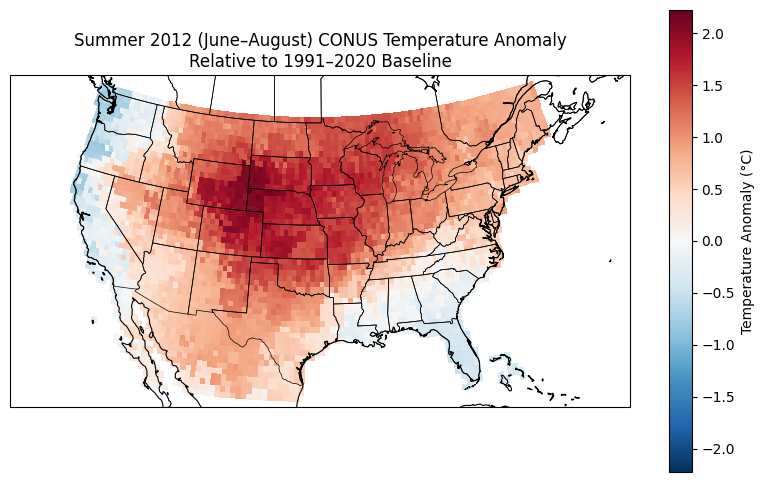

In [54]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# YOUR CODE HERE
import matplotlib.pyplot as plt

# Compute mean summer 2012 anomaly
summer_2012 = anomaly.sel(time=slice('2012-06', '2012-08')).mean(dim='time')

# Choose projection
projection = ccrs.LambertConformal(central_longitude=-96, central_latitude=39)

# Make figure
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection})

# Plot data
summer_2012.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    center=0,
    cbar_kwargs={'label': 'Temperature Anomaly (°C)'}
)

# Add map features
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

# Optional: limit view to CONUS
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Title
ax.set_title('Summer 2012 (June–August) CONUS Temperature Anomaly\nRelative to 1991–2020 Baseline')

plt.show()